# Audit kvaliteta i oporavak transakcionih podataka: Dirty Cafe Sales

Notebook prikazuje audit kvaliteta, rule-based oporavak i analizu efekta kvaliteta podataka nad skupom `dirty_cafe_sales.csv`.


## Okvir analize

Notebook je organizovan u sest faza:

1. audit sirovog skupa,
2. klasifikacija problema u podacima,
3. rule-based oporavak,
4. poredjenje kvaliteta pre i posle oporavka,
5. EDA nad oporavljenim podacima,
6. ML eksperiment koji meri efekat degradacije i oporavka.


In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="ticks")

MENU_PRICES = {
    "Coffee": 2.0,
    "Tea": 1.5,
    "Sandwich": 4.0,
    "Salad": 5.0,
    "Cake": 3.0,
    "Cookie": 1.0,
    "Smoothie": 4.0,
    "Juice": 3.0,
}

INVALID_TOKENS = {"ERROR", "UNKNOWN"}
RANDOM_STATE = 42


In [4]:
raw = pd.read_csv("./cafe_sales.csv")
raw.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Receipt Modifier
0,TXN_1961373,Coffee,2,2.0,3.60,Credit Card,Takeaway,2023-09-08,loyalty_discount
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,none
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19,none
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,none
4,TXN_3160411,Coffee,2,2.0,3.40,Digital Wallet,In-store,2023-06-11,combo_discount


## Faza A: Audit sirovog skupa

U prvoj fazi proveravamo koliko je skup podataka stvarno upotrebljiv. Posebno posmatramo razliku izmedju formalno popunjenih vrednosti i vrednosti koje su validne za dalju analizu.


In [5]:
audit_overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_null": raw.notna().sum(),
    "null_pct": (raw.isna().mean() * 100).round(2),
    "unique": raw.nunique(dropna=False)
})
audit_overview


,dtype,non_null,null_pct,unique
Transaction ID,str,10000,0.00,10000
Item,str,9667,3.33,11
Quantity,str,9862,1.38,8
Price Per Unit,str,9821,1.79,9
Total Spent,str,9827,1.73,88
Payment Method,str,7421,25.79,6
Location,str,6735,32.65,5
Transaction Date,str,9841,1.59,368
Receipt Modifier,str,10000,0.00,5


In [6]:
def normalize_tokens(frame):
    df = frame.copy()
    for col in ["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]:
        df[col] = df[col].replace(list(INVALID_TOKENS), np.nan)
    return df


def build_typed_view(frame):
    df = frame.copy()
    df["Quantity_num"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["Price_num"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
    df["Total_num"] = pd.to_numeric(df["Total Spent"], errors="coerce")
    df["TransactionDate_dt"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
    return df


def quality_scorecard(df):
    rows = {
        "Item": df["Item"].notna().sum(),
        "Quantity": df["Quantity_num"].notna().sum(),
        "Price Per Unit": df["Price_num"].notna().sum(),
        "Total Spent": df["Total_num"].notna().sum(),
        "Payment Method": df["Payment Method"].notna().sum(),
        "Location": df["Location"].notna().sum(),
        "Transaction Date": df["TransactionDate_dt"].notna().sum(),
    }
    out = pd.DataFrame.from_dict(rows, orient="index", columns=["usable_values"])
    out["usable_pct"] = (out["usable_values"] / len(df) * 100).round(2)
    return out


In [7]:
stage_raw = build_typed_view(normalize_tokens(raw))
scorecard_raw = quality_scorecard(stage_raw)
scorecard_raw


,usable_values,usable_pct
Item,9031,90.31
Quantity,9521,95.21
Price Per Unit,9467,94.67
Total Spent,9498,94.98
Payment Method,6822,68.22
Location,6039,60.39
Transaction Date,9540,95.40


Ovaj prikaz meri upotrebljivost kolona, a ne samo broj nepraznih vrednosti. Time se lakse uocava razlika izmedju nedostajucih podataka i nevalidnih tokena kao sto su `ERROR` i `UNKNOWN`.


In [8]:
issue_matrix = pd.DataFrame(index=raw.columns)
issue_matrix["missing"] = raw.isna().sum()
issue_matrix["ERROR"] = raw.astype(str).eq("ERROR").sum()
issue_matrix["UNKNOWN"] = raw.astype(str).eq("UNKNOWN").sum()
issue_matrix["issue_total"] = issue_matrix.sum(axis=1)
issue_matrix.sort_values("issue_total", ascending=False)


,missing,ERROR,UNKNOWN,issue_total
Location,3265,358,338,3961
Payment Method,2579,306,293,3178
Item,333,292,344,969
Price Per Unit,179,190,164,533
Total Spent,173,164,165,502
Quantity,138,170,171,479
Transaction Date,159,142,159,460
Transaction ID,0,0,0,0
Receipt Modifier,0,0,0,0


In [9]:
print("Broj duplikata redova:", raw.duplicated().sum())
print("Broj duplikata Transaction ID:", raw["Transaction ID"].duplicated().sum())

suspicious_preview = raw[
    raw[["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]]
    .astype(str)
    .apply(lambda s: s.isin(INVALID_TOKENS))
    .any(axis=1)
]
suspicious_preview.head(10)


Broj duplikata redova: 0
Broj duplikata Transaction ID: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Receipt Modifier
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19,none
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,none
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06,service_fee
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28,none
11,TXN_3051279,Sandwich,2,4.0,8.0,Credit Card,Takeaway,ERROR,none
14,TXN_8915701,ERROR,2,1.5,3.0,NaN,In-store,2023-03-21,loyalty_discount
18,TXN_8876618,Cake,5,3.0,16.50,Cash,ERROR,2023-03-25,service_fee
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04,service_fee
25,TXN_7958992,Smoothie,3,4.0,NaN,UNKNOWN,UNKNOWN,2023-12-13,none
29,TXN_7640952,Cake,4,3.0,10.80,Digital Wallet,Takeaway,ERROR,loyalty_discount


## Faza B: Taksonomija problema

U ovoj fazi grupisemo probleme po tipu: nedostajuce vrednosti, nevalidne kategorije, numericka ostecenja i odstupanja u odnosu na ocekivanu strukturu transakcije.


In [10]:
typed = stage_raw.copy()
typed["expected_price"] = typed["Item"].map(MENU_PRICES)
typed["expected_total"] = typed["Quantity_num"] * typed["Price_num"]

typed["flag_item_missing"] = typed["Item"].isna()
typed["flag_quantity_missing"] = typed["Quantity_num"].isna()
typed["flag_price_missing"] = typed["Price_num"].isna()
typed["flag_total_missing"] = typed["Total_num"].isna()
typed["flag_payment_missing"] = typed["Payment Method"].isna()
typed["flag_location_missing"] = typed["Location"].isna()
typed["flag_date_missing"] = typed["TransactionDate_dt"].isna()

typed["flag_price_conflict"] = (
    typed["Item"].isin(MENU_PRICES.keys())
    & typed["Price_num"].notna()
    & (typed["Price_num"] != typed["expected_price"])
)

typed["flag_total_conflict"] = (
    typed["Quantity_num"].notna()
    & typed["Price_num"].notna()
    & typed["Total_num"].notna()
    & (~np.isclose(typed["Total_num"], typed["expected_total"]))
)

typed[[c for c in typed.columns if c.startswith("flag_")]].sum().sort_values(ascending=False)


flag_location_missing    3961
flag_total_conflict      3272
flag_payment_missing     3178
flag_item_missing         969
flag_price_missing        533
flag_total_missing        502
flag_quantity_missing     479
flag_date_missing         460
flag_price_conflict         0
dtype: int64

In [11]:
issue_summary = pd.Series({
    "Missing location": int(typed["flag_location_missing"].sum()),
    "Missing payment": int(typed["flag_payment_missing"].sum()),
    "Missing item": int(typed["flag_item_missing"].sum()),
    "Missing quantity": int(typed["flag_quantity_missing"].sum()),
    "Missing price": int(typed["flag_price_missing"].sum()),
    "Missing total": int(typed["flag_total_missing"].sum()),
    "Missing date": int(typed["flag_date_missing"].sum()),
    "Price conflicts": int(typed["flag_price_conflict"].sum()),
    "Total conflicts": int(typed["flag_total_conflict"].sum()),
}).sort_values()
issue_summary


Price conflicts        0
Missing date         460
Missing quantity     479
Missing total        502
Missing price        533
Missing item         969
Missing payment     3178
Total conflicts     3272
Missing location    3961
dtype: int64

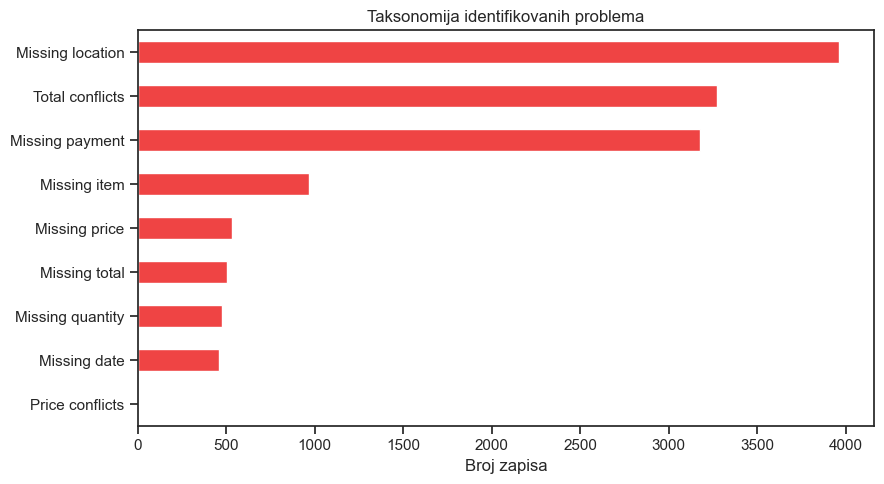

In [12]:
plt.figure(figsize=(9, 5))
issue_summary.plot(kind="barh", color="#ef4444")
plt.title("Taksonomija identifikovanih problema")
plt.xlabel("Broj zapisa")
plt.ylabel("")
plt.tight_layout()
plt.show()


U ovoj varijanti skupa kolona `Receipt Modifier` uvodi dodatni poslovni kontekst, pa odstupanje u `Total Spent` ne mora uvek znaciti gresku. Zbog toga razlikujemo ostecen zapis od legitimnog odstupanja koje nije objasnjeno samo osnovnim cenovnikom.


## Faza C: Rule engine za oporavak podataka

Oporavak zasnivamo na jednostavnim pravilima menija i aritmeticke veze izmedju kolicine, cene i ukupnog racuna. Cilj je da se popravljaju samo vrednosti koje mogu da se vrate pouzdanim pravilom.


In [13]:
recovered = typed.copy()
repair_log = {}

mask = recovered["Price_num"].isna() & recovered["expected_price"].notna()
repair_log["price_from_item"] = int(mask.sum())
recovered.loc[mask, "Price_num"] = recovered.loc[mask, "expected_price"]

mask = recovered["Total_num"].isna() & recovered["Quantity_num"].notna() & recovered["Price_num"].notna()
repair_log["total_from_quantity_price"] = int(mask.sum())
recovered.loc[mask, "Total_num"] = recovered.loc[mask, "Quantity_num"] * recovered.loc[mask, "Price_num"]

mask = recovered["Quantity_num"].isna() & recovered["Total_num"].notna() & recovered["Price_num"].notna()
ratio = recovered.loc[mask, "Total_num"] / recovered.loc[mask, "Price_num"]
valid_ratio = ratio.isin([1, 2, 3, 4, 5])
repair_log["quantity_from_total_price"] = int(valid_ratio.sum())
recovered.loc[ratio.index[valid_ratio], "Quantity_num"] = ratio[valid_ratio]

price_to_items = {}
for item, price in MENU_PRICES.items():
    price_to_items.setdefault(price, []).append(item)

repair_log["item_from_unique_price"] = 0
mask = recovered["Item"].isna() & recovered["Price_num"].notna()
for price, items in price_to_items.items():
    if len(items) == 1:
        unique_mask = mask & (recovered["Price_num"] == price)
        repair_log["item_from_unique_price"] += int(unique_mask.sum())
        recovered.loc[unique_mask, "Item"] = items[0]

recovered["Payment Method"] = recovered["Payment Method"].fillna("Unknown")
recovered["Location"] = recovered["Location"].fillna("Unknown")
recovered["Month"] = recovered["TransactionDate_dt"].dt.month
recovered["Weekday"] = recovered["TransactionDate_dt"].dt.day_name()
recovered["Weekend"] = recovered["TransactionDate_dt"].dt.dayofweek.isin([5, 6])

repair_log


{'price_from_item': 479,
 'total_from_quantity_price': 479,
 'quantity_from_total_price': 456,
 'item_from_unique_price': 468}

In [14]:
recovery_table = pd.DataFrame.from_dict(repair_log, orient="index", columns=["recovered_rows"])
recovery_table["share_of_dataset_pct"] = (recovery_table["recovered_rows"] / len(recovered) * 100).round(2)
recovery_table.sort_values("recovered_rows", ascending=False)


,recovered_rows,share_of_dataset_pct
price_from_item,479,4.79
total_from_quantity_price,479,4.79
item_from_unique_price,468,4.68
quantity_from_total_price,456,4.56


Rule-based pristup smanjuje rizik od proizvoljne imputacije i zadrzava znacenje transakcije tamo gde je oporavak opravdan.


In [15]:
scorecard_recovered = quality_scorecard(recovered)
comparison = scorecard_raw.join(scorecard_recovered, lsuffix="_before", rsuffix="_after")
comparison["gain_values"] = comparison["usable_values_after"] - comparison["usable_values_before"]
comparison["gain_pct_points"] = (comparison["usable_pct_after"] - comparison["usable_pct_before"]).round(2)
comparison


,usable_values_before,usable_pct_before,usable_values_after,usable_pct_after,gain_values,gain_pct_points
Item,9031,90.31,9499,94.99,468,4.68
Quantity,9521,95.21,9977,99.77,456,4.56
Price Per Unit,9467,94.67,9946,99.46,479,4.79
Total Spent,9498,94.98,9977,99.77,479,4.79
Payment Method,6822,68.22,10000,100.00,3178,31.78
Location,6039,60.39,10000,100.00,3961,39.61
Transaction Date,9540,95.40,9540,95.40,0,0.00


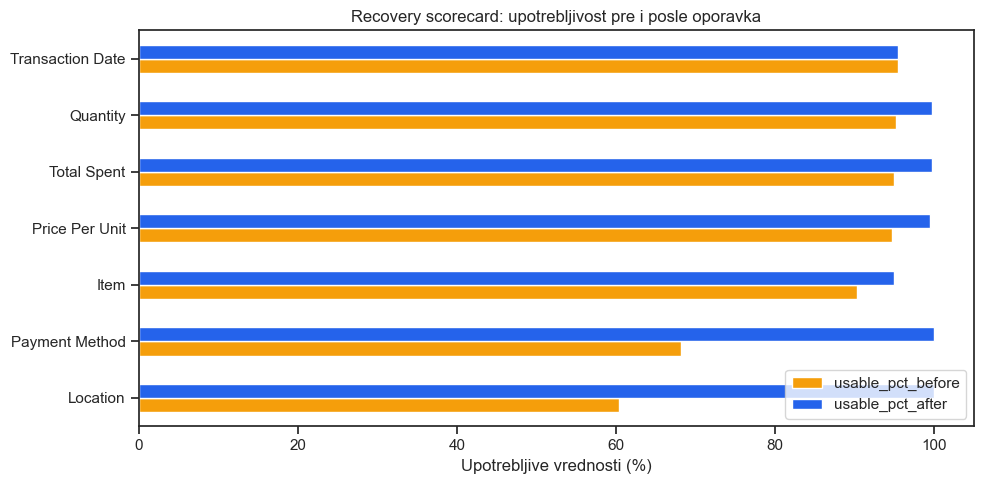

In [16]:
plot_df = comparison[["usable_pct_before", "usable_pct_after"]].sort_values("usable_pct_before")
plot_df.plot(kind="barh", figsize=(10, 5), color=["#f59e0b", "#2563eb"])
plt.title("Recovery scorecard: upotrebljivost pre i posle oporavka")
plt.xlabel("Upotrebljive vrednosti (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()


Najveci formalni dobitak vidi se kod `Location` i `Payment Method`, dok se kod numerickog jezgra transakcije vidi stvarni oporavak informacije.


## Faza D: Sloj pouzdanosti zapisa

Posle oporavka uvodimo jednostavan nivo poverenja po redu kako bismo razlikovali zapise visoke, srednje i niske pouzdanosti.


In [17]:
recovered["known_core_fields"] = recovered[["Item", "Quantity_num", "Price_num", "Total_num"]].notna().sum(axis=1)

conditions = [
    (recovered["known_core_fields"] == 4) & recovered["TransactionDate_dt"].notna(),
    (recovered["known_core_fields"] >= 3),
]
choices = ["high", "medium"]
recovered["trust_tier"] = np.select(conditions, choices, default="low")

trust_summary = pd.DataFrame({
    "rows": recovered["trust_tier"].value_counts(),
    "pct": (recovered["trust_tier"].value_counts(normalize=True) * 100).round(2)
})
trust_summary


,rows,pct
trust_tier,,
high,9044,90.44
medium,882,8.82
low,74,0.74


In [18]:
recovered["revenue_known"] = recovered["Total_num"].notna()
coverage_table = pd.DataFrame({
    "count": recovered.groupby("trust_tier")["revenue_known"].size(),
    "revenue_available_pct": (recovered.groupby("trust_tier")["revenue_known"].mean() * 100).round(2)
})
coverage_table


,count,revenue_available_pct
trust_tier,,
high,9044,100.00
low,74,68.92
medium,882,100.00


Ovaj sloj olaksava dalju analizu jer omogucava da se izvestaji i modeli grade nad pouzdanijim delom skupa.


## Faza E: EDA nad oporavljenim podacima

Poslovnu analizu radimo nad oporavljenim podacima kako bi zakljucci bili zasnovani na stabilnijem i upotrebljivijem skupu.


In [19]:
revenue_by_item = (
    recovered.dropna(subset=["Item", "Total_num"])
    .groupby("Item")
    .agg(
        transactions=("Transaction ID", "count"),
        total_revenue=("Total_num", "sum"),
        avg_ticket=("Total_num", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)
revenue_by_item


,transactions,total_revenue,avg_ticket
Item,,,
Salad,1268,19003.25,14.986790
Sandwich,1127,13733.40,12.185803
Smoothie,1094,13374.40,12.225229
Juice,1168,10477.20,8.970205
Cake,1138,10396.95,9.136160
Coffee,1279,7741.80,6.053010
Tea,1198,5407.17,4.513497
Cookie,1207,3576.80,2.963380


In [20]:
channel_mix = pd.crosstab(recovered["Location"], recovered["Payment Method"], normalize="index").round(3)
channel_mix


Payment Method,Cash,Credit Card,Digital Wallet,Unknown
Location,,,,
In-store,0.233,0.226,0.230,0.311
Takeaway,0.220,0.221,0.246,0.313
Unknown,0.225,0.233,0.215,0.327


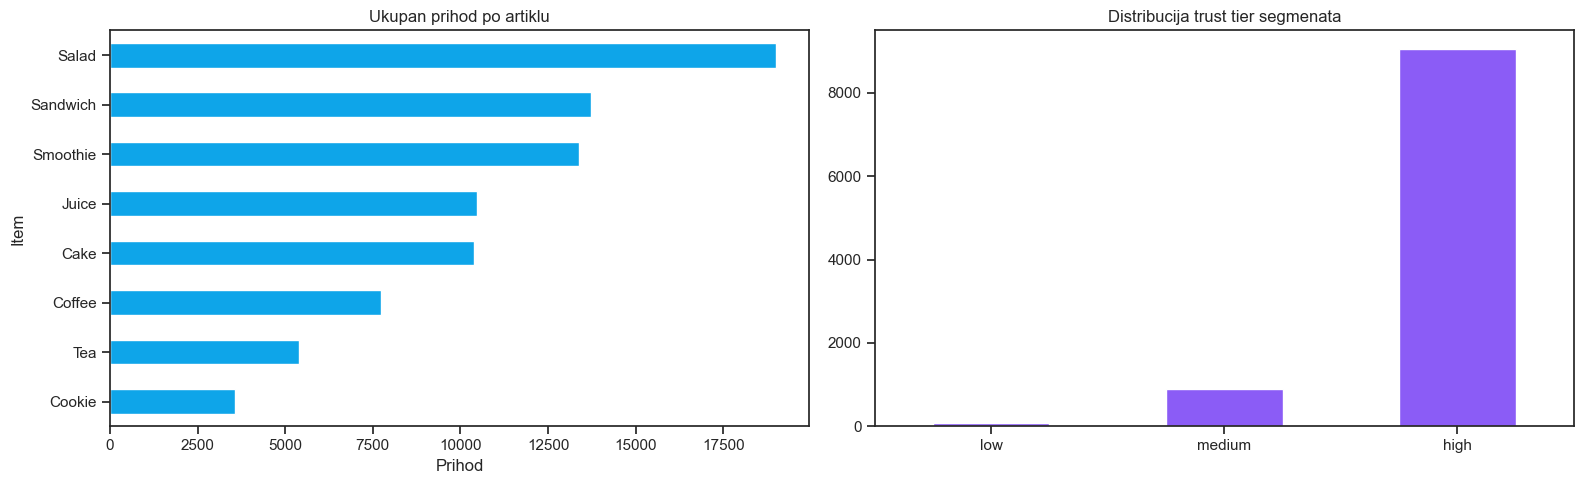

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

revenue_by_item["total_revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#0ea5e9")
axes[0].set_title("Ukupan prihod po artiklu")
axes[0].set_xlabel("Prihod")

trust_summary.loc[["low", "medium", "high"], "rows"].plot(kind="bar", ax=axes[1], color="#8b5cf6")
axes[1].set_title("Distribucija trust tier segmenata")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


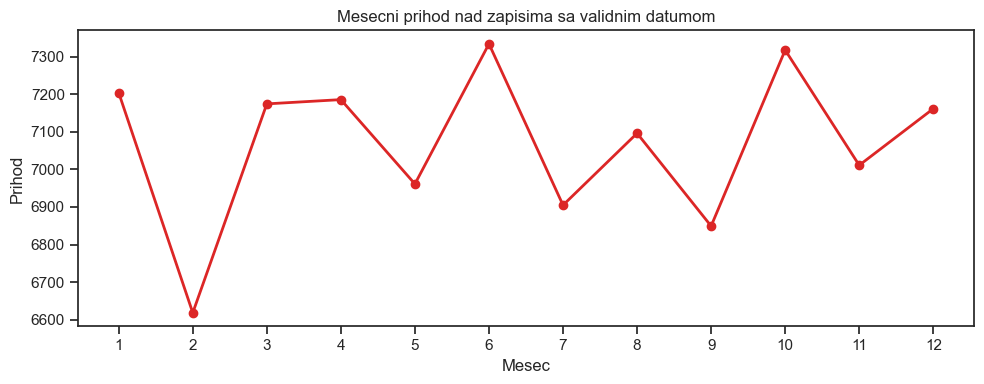

In [22]:
monthly_revenue = (
    recovered.dropna(subset=["Month", "Total_num"])
    .groupby("Month")["Total_num"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 4))
monthly_revenue.plot(marker="o", linewidth=2, color="#dc2626")
plt.title("Mesecni prihod nad zapisima sa validnim datumom")
plt.xlabel("Mesec")
plt.ylabel("Prihod")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## Faza F: Kontrolisani ML eksperiment nad degradiranim i oporavljenim podacima

U zavrsnoj fazi merimo kako kvalitet podataka utice na performanse modela. Koristimo tri scenarija:

- `clean_gold`: kvalitetan referentni podskup,
- `degraded_baseline`: namerno degradirana verzija istog podskupa,
- `recovered_after_rules`: verzija nakon primene pravila za oporavak.

Ciljna promenljiva je `ticket_band`, a isti model se trenira nad sva tri scenarija kako bi poredjenje bilo direktno.


,rows,train_rows,test_rows,avg_feature_completeness_pct,accuracy,macro_f1
dataset,,,,,,
clean_gold,3764,2823,941,100.00,0.9713,0.9702
degraded_baseline,3764,2823,941,77.58,0.7960,0.7928
recovered_after_rules,3764,2823,941,89.93,0.8735,0.8722


clean_gold                          degraded_baseline                          recovered                         
           precision recall f1-score  support         precision recall f1-score  support precision recall f1-score  support
low            0.975  0.997    0.986  346.000             0.863  0.803    0.832  346.000     0.926  0.870    0.897  346.000
medium         0.955  0.951    0.953  287.000             0.737  0.721    0.729  287.000     0.814  0.854    0.833  287.000
high           0.983  0.961    0.972  308.000             0.781  0.857    0.817  308.000     0.876  0.896    0.886  308.000
accuracy       0.971  0.971    0.971    0.971             0.796  0.796    0.796    0.796     0.874  0.874    0.874    0.874
macro avg      0.971  0.970    0.970  941.000             0.794  0.794    0.793  941.000     0.872  0.873    0.872  941.000

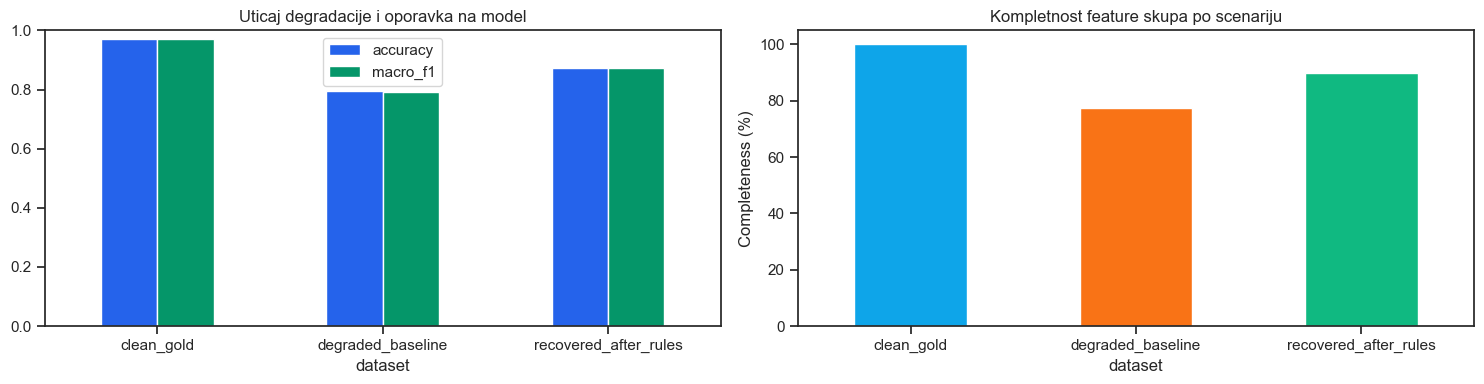

In [23]:
def add_time_features(frame):
    df = frame.copy()
    df["Month"] = df["TransactionDate_dt"].dt.month
    df["Weekday"] = df["TransactionDate_dt"].dt.day_name()
    df["WeekendFlag"] = np.where(
        df["TransactionDate_dt"].notna(),
        np.where(df["TransactionDate_dt"].dt.dayofweek.isin([5, 6]), "Weekend", "Workday"),
        np.nan,
    )
    return df


def apply_recovery_rules(frame):
    repaired = frame.copy()

    repaired["expected_price"] = repaired["Item"].map(MENU_PRICES)

    mask = repaired["Price_num"].isna() & repaired["expected_price"].notna()
    repaired.loc[mask, "Price_num"] = repaired.loc[mask, "expected_price"]

    mask = repaired["Total_num"].isna() & repaired["Quantity_num"].notna() & repaired["Price_num"].notna()
    repaired.loc[mask, "Total_num"] = repaired.loc[mask, "Quantity_num"] * repaired.loc[mask, "Price_num"]

    mask = repaired["Quantity_num"].isna() & repaired["Total_num"].notna() & repaired["Price_num"].notna()
    ratio = repaired.loc[mask, "Total_num"] / repaired.loc[mask, "Price_num"]
    valid_ratio = ratio.isin([1, 2, 3, 4, 5])
    repaired.loc[ratio.index[valid_ratio], "Quantity_num"] = ratio[valid_ratio]

    price_to_items = {}
    for item, price in MENU_PRICES.items():
        price_to_items.setdefault(price, []).append(item)

    mask = repaired["Item"].isna() & repaired["Price_num"].notna()
    for price, items in price_to_items.items():
        if len(items) == 1:
            repaired.loc[mask & (repaired["Price_num"] == price), "Item"] = items[0]

    repaired["Payment Method"] = repaired["Payment Method"].fillna("Unknown")
    repaired["Location"] = repaired["Location"].fillna("Unknown")

    return add_time_features(repaired)


def inject_quality_issues(frame, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    degraded = frame.copy()
    n = len(degraded)

    numeric_corruption = {
        "Quantity": 0.34,
        "Price Per Unit": 0.30,
        "Total Spent": 0.28,
    }
    categorical_corruption = {
        "Item": 0.28,
        "Payment Method": 0.34,
        "Location": 0.38,
        "Transaction Date": 0.20,
    }

    for col, rate in numeric_corruption.items():
        idx = rng.choice(n, size=int(n * rate), replace=False)
        degraded.iloc[idx, degraded.columns.get_loc(col)] = rng.choice(
            ["", "ERROR", "UNKNOWN"], size=len(idx), p=[0.30, 0.40, 0.30]
        )

    for col, rate in categorical_corruption.items():
        idx = rng.choice(n, size=int(n * rate), replace=False)
        degraded.iloc[idx, degraded.columns.get_loc(col)] = rng.choice(
            ["", "ERROR", "UNKNOWN"], size=len(idx), p=[0.25, 0.30, 0.45]
        )

    return degraded


gold = recovered[
    (recovered["trust_tier"] == "high")
    & recovered["Item"].notna()
    & recovered["Quantity_num"].notna()
    & recovered["Price_num"].notna()
    & recovered["Total_num"].notna()
    & recovered["Payment Method"].notna()
    & recovered["Location"].notna()
    & recovered["TransactionDate_dt"].notna()
    & (recovered["Payment Method"] != "Unknown")
    & (recovered["Location"] != "Unknown")
].copy()

gold["ticket_band"] = pd.qcut(gold["Total_num"], q=3, labels=["low", "medium", "high"])

clean_gold = gold[
    [
        "Transaction ID",
        "Item",
        "Quantity_num",
        "Price_num",
        "Total_num",
        "Payment Method",
        "Location",
        "TransactionDate_dt",
        "ticket_band",
    ]
].copy()

clean_gold["Quantity"] = clean_gold["Quantity_num"].astype(int).astype(str)
clean_gold["Price Per Unit"] = clean_gold["Price_num"].round(2).astype(str)
clean_gold["Total Spent"] = clean_gold["Total_num"].round(2).astype(str)
clean_gold["Transaction Date"] = clean_gold["TransactionDate_dt"].dt.strftime("%Y-%m-%d")

degraded_raw = inject_quality_issues(
    clean_gold[
        [
            "Transaction ID",
            "Item",
            "Quantity",
            "Price Per Unit",
            "Total Spent",
            "Payment Method",
            "Location",
            "Transaction Date",
        ]
    ]
)

degraded_typed = add_time_features(build_typed_view(normalize_tokens(degraded_raw)))
degraded_typed["ticket_band"] = clean_gold.set_index("Transaction ID").loc[
    degraded_typed["Transaction ID"], "ticket_band"
].values

recovered_synthetic = apply_recovery_rules(degraded_typed)
recovered_synthetic["ticket_band"] = degraded_typed["ticket_band"].values

clean_model = add_time_features(clean_gold.copy())

feature_cols = [
    "Item",
    "Quantity_num",
    "Price_num",
    "Payment Method",
    "Location",
    "Month",
    "Weekday",
    "WeekendFlag",
]
numeric_features = ["Quantity_num", "Price_num", "Month"]
categorical_features = ["Item", "Payment Method", "Location", "Weekday", "WeekendFlag"]

split_frame = clean_model[["Transaction ID", "ticket_band"]].drop_duplicates()
train_ids, test_ids = train_test_split(
    split_frame["Transaction ID"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=split_frame["ticket_band"],
)


def run_ticket_experiment(frame, label):
    train = frame[frame["Transaction ID"].isin(train_ids)].copy()
    test = frame[frame["Transaction ID"].isin(test_ids)].copy()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=350,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    X_train = train[feature_cols]
    X_test = test[feature_cols]
    y_train = train["ticket_band"]
    y_test = test["ticket_band"]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    report = pd.DataFrame(
        classification_report(y_test, pred, output_dict=True)
    ).T.round(3)

    return {
        "dataset": label,
        "rows": len(frame),
        "train_rows": len(train),
        "test_rows": len(test),
        "avg_feature_completeness_pct": round((1 - frame[feature_cols].isna().mean().mean()) * 100, 2),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "macro_f1": round(f1_score(y_test, pred, average="macro"), 4),
        "report": report,
    }


clean_results = run_ticket_experiment(clean_model, "clean_gold")
degraded_results = run_ticket_experiment(degraded_typed, "degraded_baseline")
recovered_results = run_ticket_experiment(recovered_synthetic, "recovered_after_rules")

experiment_summary = pd.DataFrame(
    [clean_results, degraded_results, recovered_results]
).drop(columns=["report"]).set_index("dataset")
display(experiment_summary)

report_compare = pd.concat(
    {
        "clean_gold": clean_results["report"],
        "degraded_baseline": degraded_results["report"],
        "recovered": recovered_results["report"],
    },
    axis=1,
)
display(report_compare.loc[["low", "medium", "high", "accuracy", "macro avg"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

experiment_summary[["accuracy", "macro_f1"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#2563eb", "#059669"],
)
axes[0].set_title("Uticaj degradacije i oporavka na model")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=0)

experiment_summary["avg_feature_completeness_pct"].plot(
    kind="bar",
    ax=axes[1],
    color=["#0ea5e9", "#f97316", "#10b981"],
)
axes[1].set_title("Kompletnost feature skupa po scenariju")
axes[1].set_ylabel("Completeness (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


Ovaj eksperiment prikazuje razliku izmedju cistih, degradiranih i oporavljenih podataka na istom zadatku klasifikacije.


## Zakljucak

Projekat prikazuje kompletan tok rada nad problemom kvaliteta podataka: audit, klasifikaciju problema, rule-based oporavak, procenu pouzdanosti zapisa i proveru efekta nad modelom masinskog ucenja.

Glavni nalazi su sledeci:

- skup sadrzi veliki broj nevalidnih i nedostajucih vrednosti,
- pravila zasnovana na meniju i aritmetici omogucavaju oporavak dela zapisa,
- kvalitet podataka se posle oporavka poboljsava u kljucnim kolonama,
- `trust_tier` sloj pomaze da se izdvoje pouzdaniji zapisi,
- kontrolisani ML eksperiment pokazuje razliku izmedju `clean`, `degraded` i `recovered` scenarija.
